In [1]:
import numpy as np 
import pandas as pd 

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import re
import string
from string import digits

import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize

import matplotlib.pyplot as plt
import os

2025-02-10 03:08:57.692987: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-10 03:08:57.705369: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-10 03:08:57.719339: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-10 03:08:57.723514: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-10 03:08:57.733879: I tensorflow/core/platform/cpu_feature_guar

In [2]:
def load_data(path):
    """
    Load Dataset from File
    """
    input_file = os.path.join(path)
    with open(input_file, 'r', encoding='utf-8') as f:
        return f.read()

source_path = 'data/small_vocab_en'
target_path = 'data/small_vocab_fr'
sentences_en = load_data(source_path)
source_text = sentences_en.split('\n')
sentences_fr = load_data(target_path)
target_text = sentences_fr.split('\n')
print(source_text[:10])
print(target_text[:10])

['new jersey is sometimes quiet during autumn , and it is snowy in april .', 'the united states is usually chilly during july , and it is usually freezing in november .', 'california is usually quiet during march , and it is usually hot in june .', 'the united states is sometimes mild during june , and it is cold in september .', 'your least liked fruit is the grape , but my least liked is the apple .', 'his favorite fruit is the orange , but my favorite is the grape .', 'paris is relaxing during december , but it is usually chilly in july .', 'new jersey is busy during spring , and it is never hot in march .', 'our least liked fruit is the lemon , but my least liked is the grape .', 'the united states is sometimes busy during january , and it is sometimes warm in november .']
["new jersey est parfois calme pendant l' automne , et il est neigeux en avril .", 'les états-unis est généralement froid en juillet , et il gèle habituellement en novembre .', 'california est généralement calme 

In [3]:
lines = pd.DataFrame({
    "English": source_text,
    "French": target_text
})
lines.head(10)

,English,French
0,"new jersey is sometimes quiet during autumn , ...",new jersey est parfois calme pendant l' automn...
1,the united states is usually chilly during jul...,les états-unis est généralement froid en juill...
2,"california is usually quiet during march , and...","california est généralement calme en mars , et..."
3,the united states is sometimes mild during jun...,"les états-unis est parfois légère en juin , et..."
4,"your least liked fruit is the grape , but my l...","votre moins aimé fruit est le raisin , mais mo..."
5,"his favorite fruit is the orange , but my favo...","son fruit préféré est l'orange , mais mon préf..."
6,"paris is relaxing during december , but it is ...","paris est relaxant en décembre , mais il est g..."
7,"new jersey is busy during spring , and it is n...","new jersey est occupé au printemps , et il est..."
8,"our least liked fruit is the lemon , but my le...","notre fruit est moins aimé le citron , mais mo..."
9,the united states is sometimes busy during jan...,"les états-unis est parfois occupé en janvier ,..."


In [4]:
lines.shape

(137861, 2)

# Data Preprocessing

In [5]:
# Lowercase all characters
lines['English']=lines['English'].apply(lambda x: x.lower())
lines['French']=lines['French'].apply(lambda x: x.lower())

In [6]:
lines

,English,French
0,"new jersey is sometimes quiet during autumn , ...",new jersey est parfois calme pendant l' automn...
1,the united states is usually chilly during jul...,les états-unis est généralement froid en juill...
2,"california is usually quiet during march , and...","california est généralement calme en mars , et..."
3,the united states is sometimes mild during jun...,"les états-unis est parfois légère en juin , et..."
4,"your least liked fruit is the grape , but my l...","votre moins aimé fruit est le raisin , mais mo..."
...,...,...
137856,"india is sometimes beautiful during spring , a...","l' inde est parfois belle au printemps , et il..."
137857,"india is never wet during summer , but it is s...","l' inde est jamais mouillé pendant l' été , ma..."
137858,"france is never chilly during january , but it...","la france est jamais froid en janvier , mais i..."
137859,"the orange is her favorite fruit , but the ban...","l'orange est son fruit préféré , mais la banan..."


In [7]:
exclude = set(string.punctuation) # Set of all special characters
print(exclude)
# Remove all the special characters
lines['English']=lines['English'].apply(lambda x: ''.join(ch for ch in x if ch not in exclude))
lines['French']=lines['French'].apply(lambda x: ''.join(ch for ch in x if ch not in exclude))

{'*', '-', '#', ')', '>', '=', '^', '"', ';', '`', '(', '/', '$', '%', '&', "'", '@', '?', '+', '|', ']', '<', '~', '}', '.', ',', '\\', ':', '{', '!', '_', '['}


In [8]:
lines

,English,French
0,new jersey is sometimes quiet during autumn a...,new jersey est parfois calme pendant l automne...
1,the united states is usually chilly during jul...,les étatsunis est généralement froid en juille...
2,california is usually quiet during march and ...,california est généralement calme en mars et ...
3,the united states is sometimes mild during jun...,les étatsunis est parfois légère en juin et i...
4,your least liked fruit is the grape but my le...,votre moins aimé fruit est le raisin mais mon...
...,...,...
137856,india is sometimes beautiful during spring an...,l inde est parfois belle au printemps et il e...
137857,india is never wet during summer but it is so...,l inde est jamais mouillé pendant l été mais ...
137858,france is never chilly during january but it ...,la france est jamais froid en janvier mais il...
137859,the orange is her favorite fruit but the bana...,lorange est son fruit préféré mais la banane ...


In [11]:
# Remove extra spaces
lines['English']=lines['English'].apply(lambda x: x.strip())
lines['French']=lines['French'].apply(lambda x: x.strip())
lines['English']=lines['English'].apply(lambda x: re.sub(" +", " ", x))
lines['French']=lines['French'].apply(lambda x: re.sub(" +", " ", x))

In [12]:
lines

,English,French
0,new jersey is sometimes quiet during autumn an...,new jersey est parfois calme pendant l automne...
1,the united states is usually chilly during jul...,les étatsunis est généralement froid en juille...
2,california is usually quiet during march and i...,california est généralement calme en mars et i...
3,the united states is sometimes mild during jun...,les étatsunis est parfois légère en juin et il...
4,your least liked fruit is the grape but my lea...,votre moins aimé fruit est le raisin mais mon ...
...,...,...
137856,india is sometimes beautiful during spring and...,l inde est parfois belle au printemps et il es...
137857,india is never wet during summer but it is som...,l inde est jamais mouillé pendant l été mais i...
137858,france is never chilly during january but it i...,la france est jamais froid en janvier mais il ...
137859,the orange is her favorite fruit but the banan...,lorange est son fruit préféré mais la banane e...


In [13]:
lines.head()

,English,French
0,new jersey is sometimes quiet during autumn an...,new jersey est parfois calme pendant l automne...
1,the united states is usually chilly during jul...,les étatsunis est généralement froid en juille...
2,california is usually quiet during march and i...,california est généralement calme en mars et i...
3,the united states is sometimes mild during jun...,les étatsunis est parfois légère en juin et il...
4,your least liked fruit is the grape but my lea...,votre moins aimé fruit est le raisin mais mon ...


In [14]:
stop_words = stopwords.words('english') 

In [15]:
corpus = []
for i in lines['English']:
  for word in i.split():
    corpus.append(word)
    
corpus

['new',
 'jersey',
 'is',
 'sometimes',
 'quiet',
 'during',
 'autumn',
 'and',
 'it',
 'is',
 'snowy',
 'in',
 'april',
 'the',
 'united',
 'states',
 'is',
 'usually',
 'chilly',
 'during',
 'july',
 'and',
 'it',
 'is',
 'usually',
 'freezing',
 'in',
 'november',
 'california',
 'is',
 'usually',
 'quiet',
 'during',
 'march',
 'and',
 'it',
 'is',
 'usually',
 'hot',
 'in',
 'june',
 'the',
 'united',
 'states',
 'is',
 'sometimes',
 'mild',
 'during',
 'june',
 'and',
 'it',
 'is',
 'cold',
 'in',
 'september',
 'your',
 'least',
 'liked',
 'fruit',
 'is',
 'the',
 'grape',
 'but',
 'my',
 'least',
 'liked',
 'is',
 'the',
 'apple',
 'his',
 'favorite',
 'fruit',
 'is',
 'the',
 'orange',
 'but',
 'my',
 'favorite',
 'is',
 'the',
 'grape',
 'paris',
 'is',
 'relaxing',
 'during',
 'december',
 'but',
 'it',
 'is',
 'usually',
 'chilly',
 'in',
 'july',
 'new',
 'jersey',
 'is',
 'busy',
 'during',
 'spring',
 'and',
 'it',
 'is',
 'never',
 'hot',
 'in',
 'march',
 'our',
 'leas

In [16]:
from collections import Counter
import operator

english_words_counts = Counter(corpus)
english_words_counts = sorted(english_words_counts.items(), key = operator.itemgetter(1), reverse = True)
english_words_counts

[('is', 205858),
 ('in', 75525),
 ('it', 75137),
 ('during', 74933),
 ('the', 67628),
 ('but', 63987),
 ('and', 59850),
 ('sometimes', 37746),
 ('usually', 37507),
 ('never', 37500),
 ('favorite', 28332),
 ('least', 27564),
 ('fruit', 27192),
 ('most', 14934),
 ('loved', 14166),
 ('liked', 14046),
 ('new', 12197),
 ('paris', 11334),
 ('india', 11277),
 ('united', 11270),
 ('states', 11270),
 ('california', 11250),
 ('jersey', 11225),
 ('france', 11170),
 ('china', 10953),
 ('he', 10786),
 ('she', 10786),
 ('grapefruit', 10692),
 ('your', 9734),
 ('my', 9700),
 ('his', 9700),
 ('her', 9700),
 ('fall', 9134),
 ('june', 9133),
 ('spring', 9102),
 ('january', 9090),
 ('winter', 9038),
 ('march', 9023),
 ('autumn', 9004),
 ('may', 8995),
 ('nice', 8984),
 ('september', 8958),
 ('july', 8956),
 ('april', 8954),
 ('november', 8951),
 ('summer', 8948),
 ('december', 8945),
 ('february', 8942),
 ('our', 8932),
 ('their', 8932),
 ('freezing', 8928),
 ('pleasant', 8916),
 ('beautiful', 8915),
 ('

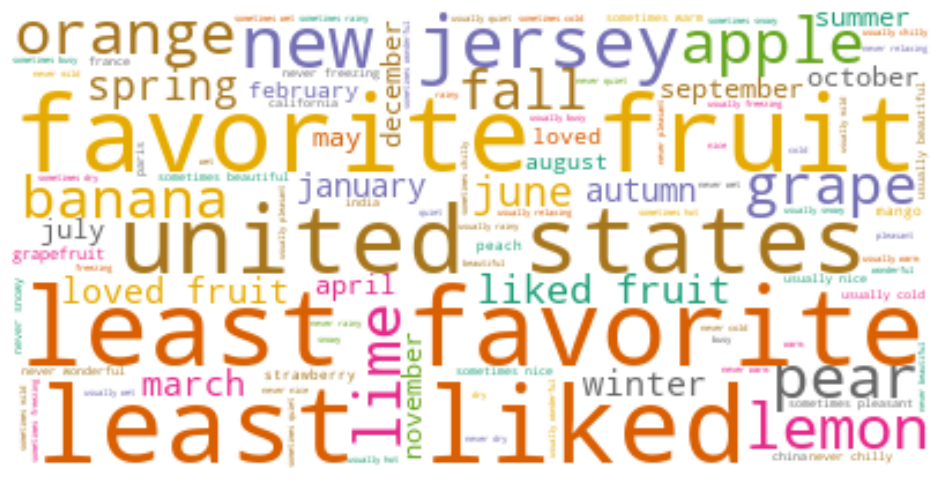

In [17]:
from wordcloud import WordCloud

wc = WordCloud(stopwords=stop_words, background_color="white", colormap="Dark2",
               max_font_size=150 )

wc.generate(" ".join(lines.English))

plt.rcParams["figure.figsize"] = (16,6)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
    
plt.show()


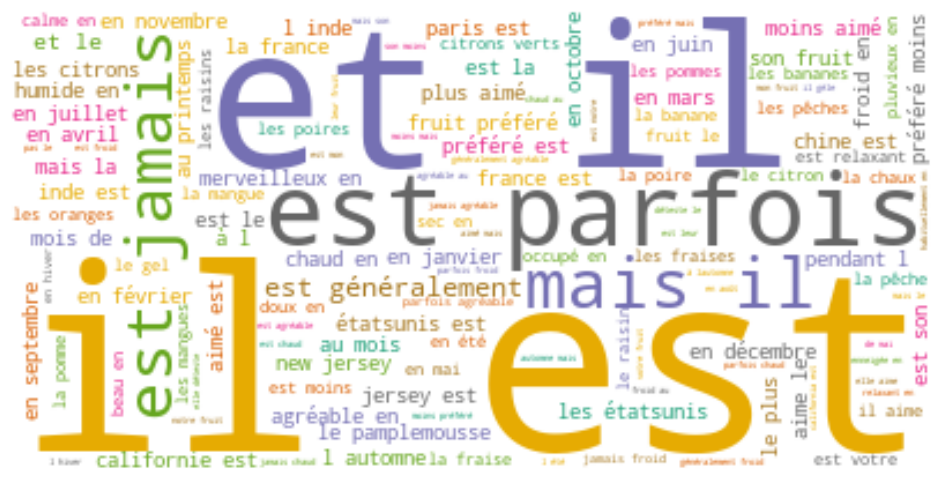

In [18]:
from wordcloud import WordCloud

wc = WordCloud(stopwords=stop_words, background_color="white", colormap="Dark2",
               max_font_size=150 )

wc.generate(" ".join(lines.French))

plt.rcParams["figure.figsize"] = (16,6)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
    
plt.show()

In [19]:
maxlen_english = -1
for doc in lines.English:
    tokens = nltk.word_tokenize(doc)
    if(maxlen_english < len(tokens)):
        maxlen_english = len(tokens)
print("The maximum number of words in any document = ", maxlen_english)

The maximum number of words in any document =  15


In [20]:
# obtain the count of french words
french_corpus = []
for i in lines['French']:
  for word in i.split():
    french_corpus.append(word)
french_corpus

['new',
 'jersey',
 'est',
 'parfois',
 'calme',
 'pendant',
 'l',
 'automne',
 'et',
 'il',
 'est',
 'neigeux',
 'en',
 'avril',
 'les',
 'étatsunis',
 'est',
 'généralement',
 'froid',
 'en',
 'juillet',
 'et',
 'il',
 'gèle',
 'habituellement',
 'en',
 'novembre',
 'california',
 'est',
 'généralement',
 'calme',
 'en',
 'mars',
 'et',
 'il',
 'est',
 'généralement',
 'chaud',
 'en',
 'juin',
 'les',
 'étatsunis',
 'est',
 'parfois',
 'légère',
 'en',
 'juin',
 'et',
 'il',
 'fait',
 'froid',
 'en',
 'septembre',
 'votre',
 'moins',
 'aimé',
 'fruit',
 'est',
 'le',
 'raisin',
 'mais',
 'mon',
 'moins',
 'aimé',
 'est',
 'la',
 'pomme',
 'son',
 'fruit',
 'préféré',
 'est',
 'lorange',
 'mais',
 'mon',
 'préféré',
 'est',
 'le',
 'raisin',
 'paris',
 'est',
 'relaxant',
 'en',
 'décembre',
 'mais',
 'il',
 'est',
 'généralement',
 'froid',
 'en',
 'juillet',
 'new',
 'jersey',
 'est',
 'occupé',
 'au',
 'printemps',
 'et',
 'il',
 'est',
 'jamais',
 'chaude',
 'en',
 'mars',
 'notre

In [21]:
import operator

french_words_counts = Counter(french_corpus)
french_words_counts = sorted(french_words_counts.items(), key = operator.itemgetter(1), reverse = True)
french_words_counts

[('est', 196809),
 ('en', 105768),
 ('il', 84115),
 ('les', 65255),
 ('mais', 63987),
 ('et', 59851),
 ('la', 49861),
 ('parfois', 37746),
 ('jamais', 37215),
 ('le', 35306),
 ('l', 32917),
 ('généralement', 31292),
 ('moins', 27557),
 ('aimé', 25852),
 ('au', 25738),
 ('fruit', 23626),
 ('préféré', 23305),
 ('agréable', 17751),
 ('froid', 16794),
 ('son', 16496),
 ('chaud', 16405),
 ('de', 15070),
 ('plus', 14934),
 ('automne', 14727),
 ('mois', 14350),
 ('à', 13870),
 ('elle', 12080),
 ('citrons', 11679),
 ('paris', 11334),
 ('inde', 11277),
 ('étatsunis', 11267),
 ('france', 11170),
 ('jersey', 11052),
 ('new', 11047),
 ('chine', 10936),
 ('pendant', 10741),
 ('pamplemousse', 10140),
 ('mon', 9403),
 ('votre', 9368),
 ('juin', 9133),
 ('printemps', 9100),
 ('janvier', 9090),
 ('hiver', 9038),
 ('mars', 9023),
 ('été', 8999),
 ('mai', 8995),
 ('septembre', 8958),
 ('juillet', 8956),
 ('avril', 8954),
 ('novembre', 8951),
 ('décembre', 8945),
 ('février', 8942),
 ('octobre', 8911),
 (

In [22]:
# append the values to a list for visuaization purpose
french_words = []
french_counts = []
for i in range(len(french_words_counts)):
  french_words.append(french_words_counts[i][0])
  french_counts.append(french_words_counts[i][1])

In [23]:
maxlen_french = -1
for doc in lines.French:
    tokens = nltk.word_tokenize(doc)
    if(maxlen_french < len(tokens)):
        maxlen_french = len(tokens)
print("The maximum number of words in any document = ", maxlen_french)

The maximum number of words in any document =  21


In [24]:
from tensorflow.keras.preprocessing.text import one_hot, Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
def tokenize_and_pad(x, maxlen):
  tokenizer = Tokenizer(char_level = False)
  tokenizer.fit_on_texts(x)
  sequences = tokenizer.texts_to_sequences(x)
  padded = pad_sequences(sequences, maxlen = maxlen, padding = 'post')
  return tokenizer, sequences, padded

In [25]:
# tokenize and padding to the data 
x_tokenizer, x_sequences, x_padded = tokenize_and_pad(lines.English, maxlen_english)
y_tokenizer, y_sequences, y_padded = tokenize_and_pad(lines.French,  maxlen_french)

In [26]:
# Total vocab size, since we added padding we add 1 to the total word count
english_vocab_size = len(english_words_counts) + 1
print("Complete English Vocab Size:", english_vocab_size)

Complete English Vocab Size: 200


In [27]:
french_vocab_size = len(french_words_counts) + 1
print("Complete French Vocab Size:", french_vocab_size)

Complete French Vocab Size: 345


In [28]:
# function to obtain the text from padded variables
def pad_to_text(padded, tokenizer):

    id_to_word = {id: word for word, id in tokenizer.word_index.items()}
    id_to_word[0] = ''

    return ' '.join([id_to_word[j] for j in padded])

In [29]:
pad_to_text(y_padded[0], y_tokenizer)

'new jersey est parfois calme pendant l automne et il est neigeux en avril       '

In [30]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_padded, y_padded, test_size = 0.1)

# Encoder and Decoder Architecture

In [31]:
print(english_vocab_size, french_vocab_size, maxlen_english, maxlen_french)

200 345 15 21


In [32]:
from tensorflow.keras.layers import Dense, Flatten, TimeDistributed, RepeatVector, Embedding, Input, LSTM, Conv1D, MaxPool1D, Bidirectional
from tensorflow.keras.models import Sequential

english_vocab_size, french_vocab_size, maxlen_english, maxlen_french = 200, 345, 15, 21

# Sequential Model
model = Sequential()
# embedding layer

model.add(Embedding(english_vocab_size, 256, input_length = maxlen_english, mask_zero = True))
# encoder
model.add(LSTM(256, return_sequences=True, unroll=True))  # Keep 3D output for next LSTM
model.add(LSTM(256, unroll=True))

model.add(RepeatVector(maxlen_french))

# decoder
model.add(LSTM(256, return_sequences=True, unroll=True))
model.add(LSTM(256, return_sequences=True, unroll=True))


model.add(TimeDistributed(Dense(french_vocab_size, activation ='softmax')))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.build((None, maxlen_english))  
model.summary()

/home/ghaidaa/anaconda3/envs/tf_env_v2/lib/python3.9/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1739149773.492077  122710 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739149773.527636  122710 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739149773.528795  122710 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at htt

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 256)        │        51,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 21, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 21, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 21, 345)        │        88,665 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,241,113 (8.55 MB)

 Trainable params: 2,241,113 (8.55 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# change the shape of target from 2D to 3D
y_train = np.expand_dims(y_train, axis = 2)
y_train.shape

(124074, 21, 1)

# Coverting text into one hot encoding 

In [34]:
# train the model
model.fit(x_train, y_train, batch_size=1024, validation_split= 0.1, epochs=30)

Epoch 1/30


I0000 00:00:1739149782.526987  122942 service.cc:146] XLA service 0x124bb860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739149782.527007  122942 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-02-10 03:09:42.776461: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1739149784.229915  122942 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-02-10 03:09:44.797778: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2025-02-10 03:09:46.162328: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_232', 8 bytes spil

109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4213 - loss: 3.4012

W0000 00:00:1739149812.032360  122942 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-02-10 03:10:15.477360: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_249', 32 bytes spill stores, 32 bytes spill loads

2025-02-10 03:10:38.620948: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_10', 4 bytes spill stores, 28 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_concatenate_fusion_10', 8 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_concatenate_fusion_9', 16 bytes spill stores, 16 bytes spill loads



110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.4217 - loss: 3.3954

W0000 00:00:1739149841.353735  122943 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-02-10 03:10:51.387201: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_log_reduce_fusion_1', 52 bytes spill stores, 56 bytes spill loads

W0000 00:00:1739149852.863116  122943 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-02-10 03:10:54.510753: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_90', 32 bytes spill stores, 32 bytes spill loads



110/110 ━━━━━━━━━━━━━━━━━━━━ 93s 617ms/step - accuracy: 0.4221 - loss: 3.3897 - val_accuracy: 0.4965 - val_loss: 2.2628
Epoch 2/30


2025-02-10 03:11:07.805961: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_log_reduce_fusion_1', 44 bytes spill stores, 48 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_multiply_fusion_20', 4 bytes spill stores, 4 bytes spill loads



110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.5331 - loss: 2.1187 - val_accuracy: 0.5303 - val_loss: 1.9608
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.5662 - loss: 1.8057 - val_accuracy: 0.6005 - val_loss: 1.4823
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.6082 - loss: 1.4350 - val_accuracy: 0.6236 - val_loss: 1.3413
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.6443 - loss: 1.2692 - val_accuracy: 0.6650 - val_loss: 1.1680
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.6756 - loss: 1.1197 - val_accuracy: 0.6526 - val_loss: 1.2257
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.6863 - loss: 1.0661 - val_accuracy: 0.7117 - val_loss: 0.9543
Epoch 8/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.7185 - loss: 0.9321 - val_accuracy: 0.7327 - val_loss: 0.9040
Epoch 9/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.7366 - loss: 0.8907 - val_accurac

In [35]:
model.save("translator_weights.keras")

In [36]:
model.load_weights("translator_weights.keras")

In [37]:
# prediction
def prediction(x, x_tokenizer = x_tokenizer, y_tokenizer = y_tokenizer):
    predictions = model.predict(x)[0]
    id_to_word = {id: word for word, id in y_tokenizer.word_index.items()}
    id_to_word[0] = ''
    return ' '.join([id_to_word[j] for j in np.argmax(predictions,1)])

In [38]:
for i in range(1):

  print('Original English word - {}\n'.format(pad_to_text(x_test[i], x_tokenizer)))
  print('Original French word - {}\n'.format(pad_to_text(y_test[i], y_tokenizer)))
  print('Predicted French word - {}\n\n\n\n'.format(prediction(x_test[i:i+1])))

Original English word - new jersey is never wonderful during spring but it is usually busy in april 

Original French word - new jersey est jamais merveilleux au printemps mais il est généralement occupé en avril       

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Predicted French word - new jersey est jamais merveilleux au printemps mais il est généralement occupé en avril       




